# Why the weak-lens Gaussian needs `Var = K2`, not `(K2 - K1^2/N)/2`

**A self-contained, brute-force proof.**

The production code models the summed convergence of all *weak* lenses on a sightline as a
single Gaussian, whose width is returned by `sigmakappaW` (`cpp/lensing.cpp:157`). It returns

$$\sigma_W \;=\; \sqrt{\,K_2 \;-\; K_1^2/N_h\,}\quad\text{with a }\pi r^2\,\mathrm d\ln r\text{ area measure.}$$

This notebook shows, from scratch, that the correct width is $\sqrt{K_2}$, and that the code is
wrong in **two independent ways**:

1. the $-K_1^2/N_h$ subtraction assumes a *fixed* number of halos, but the model draws the count
   from a **Poisson** distribution (`cpp/lensing.cpp:538`) — for a Poisson field Campbell's theorem
   gives $\mathrm{Var}=K_2$, no subtraction;
2. the area measure is $\pi r^2\,\mathrm d\ln r$ where a thin annulus has area $2\pi r^2\,\mathrm d\ln r$
   — a missing factor of 2 that halves the whole variance.

Every number below is either derived analytically, produced by a pure-Python simulation you can
re-run, or read from the C++ brute-force probe (`playground/sigmakappaw_poisson_vs_fixed.cpp`).

## The quantities, defined

- **$\kappa$ (convergence)** — dimensionless; magnification $\mu\approx 1+2\kappa$. It adds along the
  line of sight, so the total from many halos is the **sum** of each halo's $\kappa$.
- **sightline** — one line of sight to a source at $z_s=1$.
- **weak halo** — a halo far enough off the sightline that its own $\kappa$ is *below* the threshold
  $\kappa_{\rm thr}$. These are not drawn individually in production; they are bundled into the
  Gaussian whose width is `sigmakappaW`.
- **$\Sigma\kappa_{\rm weak}$** — the sum of $\kappa$ over all weak halos on one sightline. This is
  the random variable everything is about.
- **$K_1=\int n\,\kappa$** — its mean (= 0.0966); **$K_2=\int n\,\kappa^2$** — the Campbell variance.

### The strong/weak split: $N=100 \Rightarrow \kappa_{\rm thr}$
The code does **not** pick $\kappa_{\rm thr}$ directly. You pick $N=100$ = the target number of
*strong* halos per sightline, and $\kappa_{\rm thr}$ is derived by inverting
$N_h(\kappa_{\rm thr})=100$, where $N_h(\kappa_{\rm thr})$ is the expected number of halos whose
NFW convergence at the sightline exceeds $\kappa_{\rm thr}$ (`findkappathr` / `NhfNFW`,
`cpp/lensing.cpp:137,193`). Halos **above** $\kappa_{\rm thr}$ are drawn explicitly (strong);
everything **below** is the weak band this notebook is about. At $z_s=1$: $\kappa_{\rm thr}=1.278\times10^{-4}$.

In [1]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ---- locate the probe outputs (run this notebook from playground/, or edit DATA) ----
def find_data():
    for p in [Path.cwd(), Path.cwd()/"playground", Path.cwd().parent/"playground"]:
        if (p/"sigmakappaw_sums_poisson_zs1.txt").exists():
            return p
    raise FileNotFoundError("put this notebook in gw-wl-emulator/playground/ (next to the .txt files)")

DATA = find_data()
log = (DATA/"sigmakappaw_poisson_vs_fixed_zs1.log").read_text()
def grab(pat): return float(re.search(pat, log).group(1))

kappa_thr = grab(r"kappa_thr\(N=100\) = ([\d.eE+-]+)")
sigma_code = grab(r"sigmakappaW\(\) = ([\d.eE+-]+)")
n_tot = grab(r"n = ([\d.eE+-]+)")
K1 = grab(r"K1 = ([\d.eE+-]+)")
K2 = grab(r"K2 = ([\d.eE+-]+)")
print(f"from the C++ probe (z_s = 1):")
print(f"  kappa_thr (from N=100) = {kappa_thr:.4e}")
print(f"  K1 = <Sum kappa>       = {K1:.6f}")
print(f"  K2 = int n kappa^2     = {K2:.4e}")
print(f"  code sigma_W           = {sigma_code:.4e}   ->  sigma_W^2 = {sigma_code**2:.4e}")
print(f"  expected weak halos/LOS= {n_tot:,.0f}")

from the C++ probe (z_s = 1):
  kappa_thr (from N=100) = 1.2778e-04
  K1 = <Sum kappa>       = 0.096617
  K2 = int n kappa^2     = 1.7453e-06
  code sigma_W           = 9.1613e-04   ->  sigma_W^2 = 8.3929e-07
  expected weak halos/LOS= 113,350


## Part 1 — the statistics, with no astrophysics at all

Forget lensing for a moment. Put $N$ objects on a sightline, each contributing a random $\kappa$
drawn from some distribution with mean $\mu=\langle\kappa\rangle$ and second moment
$s=\langle\kappa^2\rangle$. What is $\mathrm{Var}\big(\sum_i \kappa_i\big)$?

**If $N$ is fixed** (exactly $N$ every time), the $\kappa_i$ are i.i.d. and
$$\mathrm{Var}\Big(\textstyle\sum_i\kappa_i\Big)=N\,\mathrm{Var}(\kappa)=N\,(s-\mu^2).$$
Identifying $Ns=K_2$ and $N\mu=K_1$ gives $\;\mathrm{Var}=K_2-K_1^2/N.$ **This is the code's formula.**

**If $N$ is Poisson** with mean $\bar N$ (the model's actual case), use the law of total variance:
$$\mathrm{Var}\Big(\textstyle\sum\kappa\Big)=\underbrace{\mathbb E[N]\,\mathrm{Var}(\kappa)}_{\bar N(s-\mu^2)}
+\underbrace{\mathrm{Var}(N)\,\langle\kappa\rangle^2}_{\bar N\,\mu^2}
=\bar N\,s = K_2.$$
The Poisson count fluctuations ($\mathrm{Var}(N)=\mathbb E[N]$) put **back** exactly the $\mu^2$ piece
that the fixed-count formula subtracts. **No subtraction. This is Campbell's theorem.**

The cell below proves both lines by direct simulation, with a deliberately small $\bar N=5$ so the
subtraction is a big, obvious fraction.

In [2]:
rng = np.random.default_rng(0)
Nbar = 5                       # small, so K1^2/N is a large fraction -> effect is obvious
trials = 400_000
# per-object kappa distribution: anything with mu != 0 works; use Uniform(0,1)
mu, s = 0.5, 1/3.0            # mean and 2nd moment of U(0,1)

# fixed count: exactly Nbar objects every trial
Kfix = rng.uniform(0, 1, size=(trials, Nbar)).sum(axis=1)
# Poisson count: N ~ Poisson(Nbar) objects every trial
counts = rng.poisson(Nbar, size=trials)
Kpois = np.array([rng.uniform(0, 1, k).sum() for k in counts])

K1s, K2s = Nbar*mu, Nbar*s
print(f"analytic:  K2 (=Nbar*s) = {K2s:.4f}    K2 - K1^2/Nbar = {K2s - K1s**2/Nbar:.4f}")
print(f"fixed-N  MC Var = {Kfix.var():.4f}   -> matches K2 - K1^2/N   ({K2s - K1s**2/Nbar:.4f})")
print(f"Poisson  MC Var = {Kpois.var():.4f}   -> matches K2           ({K2s:.4f})")
print(f"\nsubtraction removed by Poisson counts: {100*(K1s**2/Nbar)/K2s:.0f}% of the variance")

analytic:  K2 (=Nbar*s) = 1.6667    K2 - K1^2/Nbar = 0.4167
fixed-N  MC Var = 0.4160   -> matches K2 - K1^2/N   (0.4167)
Poisson  MC Var = 1.6611   -> matches K2           (1.6667)

subtraction removed by Poisson counts: 75% of the variance


That is the entire argument, in miniature: **the only thing that changes the variance is whether the
count is fixed or Poisson**, and the model's count is Poisson, so the answer is $K_2$.

## Part 2 — the same thing on the real weak-lensing field (brute force)

Now the real halos. The C++ probe rebuilds the weak band from the code's own ingredients
(halo mass function, NFW kernel `kappagammaNFWeps`, uniform-in-area positions) and, for each of
20,000 sightlines, draws a **Poisson** number of halos per $(z,M)$ cell, evaluates each one's
$\kappa$, and sums. No formula for the variance is assumed — it is measured from the 20,000 sums.

It also does the identical draw with the count **frozen** at exactly $n$ halos, to reproduce the
fixed-count formula as a control. We load its raw outputs and check three things.

In [3]:
sumsP = np.loadtxt(DATA/"sigmakappaw_sums_poisson_zs1.txt")   # 20000 sightline totals, Poisson counts
sumsF = np.loadtxt(DATA/"sigmakappaw_sums_frozen_zs1.txt")    # 20000 totals, frozen count
halos = np.loadtxt(DATA/"sigmakappaw_one_sightline_zs1.txt")  # every weak halo on ONE sightline
kap, zl, r = halos[:,0], halos[:,1], halos[:,2]
Nreal = len(sumsP); relerr = np.sqrt(2/(Nreal-1))

print(f"{'quantity':38s} {'value':>12s} {'/K2':>8s}")
print(f"{'brute-force Var, POISSON counts':38s} {sumsP.var():12.4e} {sumsP.var()/K2:8.4f}   <- the model's case")
print(f"{'brute-force Var, FROZEN count':38s} {sumsF.var():12.4e} {sumsF.var()/K2:8.4f}")
print(f"{'sum kappa_i^2 on ONE sightline':38s} {(kap**2).sum():12.4e} {(kap**2).sum()/K2:8.4f}   <- Campbell est., no formula")
print(f"{'analytic K2':38s} {K2:12.4e} {1.0:8.4f}")
print(f"{'analytic K2 - K1^2/n':38s} {K2-K1**2/n_tot:12.4e} {(K2-K1**2/n_tot)/K2:8.4f}")
print(f"{'code sigmakappaW^2':38s} {sigma_code**2:12.4e} {sigma_code**2/K2:8.4f}   <- what production uses")
print(f"\nPoisson brute force = K2 to {abs(1-sumsP.var()/K2)*100:.2f}% (1-sigma MC error {relerr*100:.1f}%)")

quantity                                      value      /K2
brute-force Var, POISSON counts          1.7426e-06   0.9985   <- the model's case
brute-force Var, FROZEN count            1.6241e-06   0.9306
sum kappa_i^2 on ONE sightline           1.6726e-06   0.9584   <- Campbell est., no formula
analytic K2                              1.7453e-06   1.0000
analytic K2 - K1^2/n                     1.6629e-06   0.9528
code sigmakappaW^2                       8.3929e-07   0.4809   <- what production uses

Poisson brute force = K2 to 0.15% (1-sigma MC error 1.0%)


Note the third row: on a **single** sightline, $\sum_i\kappa_i^2$ (just squaring each halo's own
$\kappa$ and adding) already estimates $K_2$ — because for a Poisson process
$\mathbb E[\sum_i f(x_i)]=\int n\,f$. So the Campbell variance is literally "add up $\kappa^2$ over the
halos you drew," with no integral and no formula. It lands within a few percent of $K_2$ (single-draw
Poisson noise), and the 20,000-sightline variance nails it to 0.15%.

The code's value is $0.48\,K_2$ — the frozen-count value (0.95) **halved**.

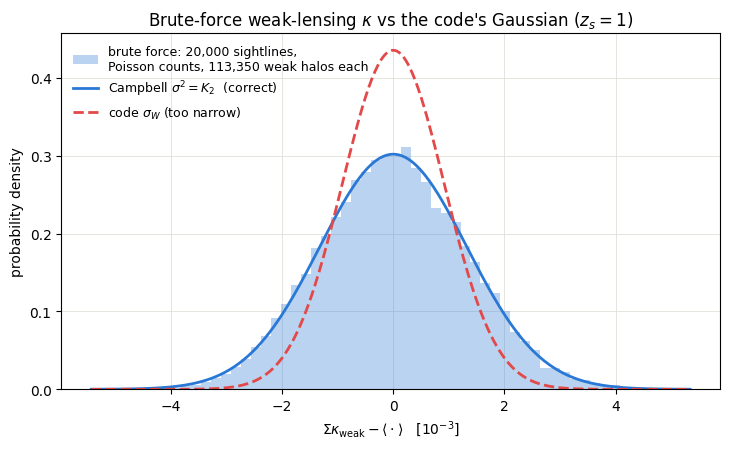

In [4]:
# ---- Figure 1: the brute-force distribution vs the two candidate Gaussians ----
INK, MUTED, BASE, GRID = "#0b0b0b", "#898781", "#c3c2b7", "#e1e0d9"
BLUE, RED = "#2a78d6", "#e34948"
fig, ax = plt.subplots(figsize=(7.4, 4.6))
d = (sumsP - K1)*1e3
ax.hist(d, bins=60, density=True, color=BLUE, alpha=0.32, edgecolor="none",
        label=f"brute force: {Nreal:,} sightlines,\nPoisson counts, {n_tot:,.0f} weak halos each")
x = np.linspace(d.min(), d.max(), 400)
g = lambda sig: np.exp(-x**2/(2*sig**2))/(sig*np.sqrt(2*np.pi))
ax.plot(x, g(np.sqrt(K2)*1e3),  color=BLUE, lw=2,          label=r"Campbell $\sigma^2=K_2$  (correct)")
ax.plot(x, g(sigma_code*1e3),   color=RED,  lw=2, ls="--", label=r"code $\sigma_W$ (too narrow)")
ax.set_xlabel(r"$\Sigma\kappa_{\rm weak}-\langle\cdot\rangle$   [$10^{-3}$]")
ax.set_ylabel("probability density")
ax.set_title("Brute-force weak-lensing $\\kappa$ vs the code's Gaussian ($z_s=1$)")
ax.legend(frameon=False, fontsize=9); ax.grid(color=GRID, lw=.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

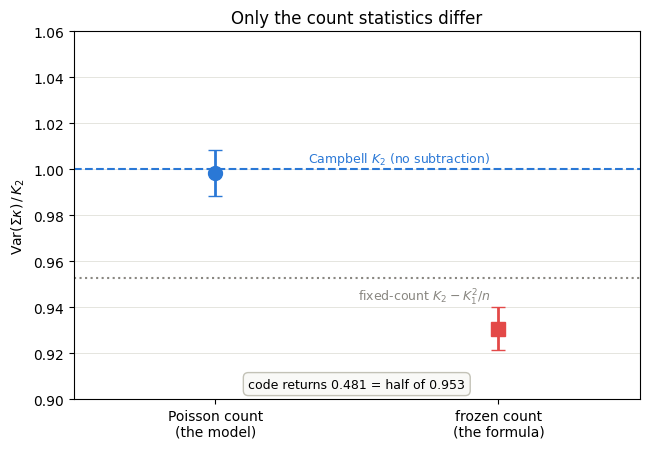

In [5]:
# ---- Figure 2: same halos, only the count statistics change ----
fig, ax = plt.subplots(figsize=(6.6, 4.6))
ax.axhline(1.0, color=BLUE, ls="--", lw=1.5)
ax.axhline((K2-K1**2/n_tot)/K2, color=MUTED, ls=":", lw=1.5)
ax.errorbar([0],[sumsP.var()/K2], yerr=[sumsP.var()/K2*relerr], fmt="o", ms=10, color=BLUE, capsize=5, lw=2)
ax.errorbar([1],[sumsF.var()/K2], yerr=[sumsF.var()/K2*relerr], fmt="s", ms=10, color=RED,  capsize=5, lw=2)
ax.text(0.97,1.001,"Campbell $K_2$ (no subtraction)", color=BLUE, ha="right", va="bottom", fontsize=9)
ax.text(0.97,(K2-K1**2/n_tot)/K2-0.004,"fixed-count $K_2-K_1^2/n$", color=MUTED, ha="right", va="top", fontsize=9)
ax.text(0.5,0.905, f"code returns {sigma_code**2/K2:.3f} = half of {(K2-K1**2/n_tot)/K2:.3f}",
        ha="center", fontsize=9, bbox=dict(boxstyle="round,pad=.4", fc="#f9f9f7", ec=BASE))
ax.set_xticks([0,1]); ax.set_xticklabels(["Poisson count\n(the model)","frozen count\n(the formula)"])
ax.set_xlim(-.5,1.5); ax.set_ylim(.90,1.06); ax.set_ylabel(r"Var$(\Sigma\kappa)\,/\,K_2$")
ax.set_title("Only the count statistics differ"); ax.grid(color=GRID, lw=.6, axis="y"); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

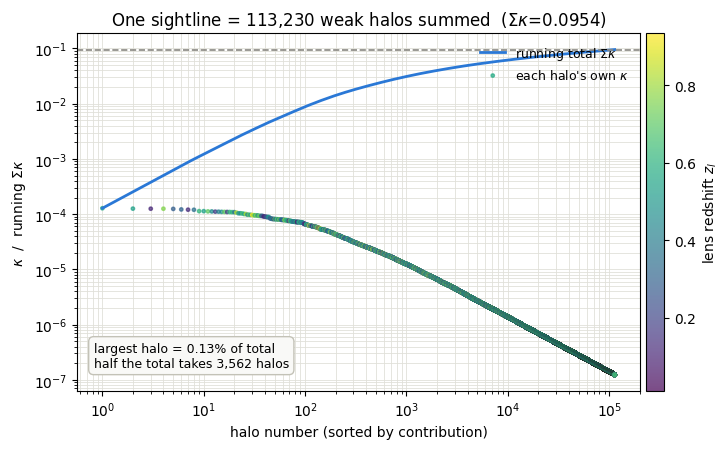

In [6]:
# ---- Figure 3: what "brute force" is -- build ONE sightline halo by halo ----
order = np.argsort(kap)[::-1]
cum = np.cumsum(kap[order]); rank = np.arange(1, len(kap)+1)
half = int(np.searchsorted(cum, 0.5*cum[-1]))+1
fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.plot(rank, cum, color=BLUE, lw=2, label=r"running total $\Sigma\kappa$")
sc = ax.scatter(rank, kap[order], c=zl[order], s=6, cmap="viridis", alpha=.7, label="each halo's own $\\kappa$")
ax.axhline(cum[-1], color=MUTED, ls="--", lw=1.2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("halo number (sorted by contribution)"); ax.set_ylabel(r"$\kappa$  /  running $\Sigma\kappa$")
ax.set_title(f"One sightline = {len(kap):,} weak halos summed  ($\\Sigma\\kappa$={cum[-1]:.4f})")
ax.text(.03,.06, f"largest halo = {100*kap[order][0]/cum[-1]:.2f}% of total\n"
                 f"half the total takes {half:,} halos",
        transform=ax.transAxes, fontsize=9, va="bottom",
        bbox=dict(boxstyle="round,pad=.4", fc="#f9f9f7", ec=BASE))
ax.legend(frameon=False, fontsize=9, loc="upper right"); ax.grid(color=GRID, lw=.6, which="both"); ax.set_axisbelow(True)
fig.colorbar(sc, ax=ax, pad=.01, fraction=.05, label="lens redshift $z_l$")
plt.tight_layout(); plt.show()

## Part 3 — the factor of 2 (the area measure)

The two bugs are independent. Part 1–2 settled the subtraction. The remaining factor of 2 is a
geometry error in `sigmakappaW`'s integrand.

The number of halos whose center lands in a thin annulus at impact parameter $r$ is
(surface density) $\times$ (annulus area). A thin annulus has area
$$\mathrm dA = 2\pi r\,\mathrm dr = 2\pi r^2\,\mathrm d\ln r.$$
But `sigmakappaW` (`cpp/lensing.cpp:185-187`) weights each shell by $\pi\,r^2\,\mathrm d\ln r$ — it
reused the **disk** area $\pi r^2$ from line 121 and appended $\mathrm d\ln r$, forgetting that
$\mathrm d(\pi r^2)/\mathrm d\ln r = 2\pi r^2$. Every accumulator ($N_h,\kappa_1,\kappa_2$) is therefore
exactly halved, and since the return is $\kappa_2-\kappa_1^2/N_h$, halving all three halves the variance:
$$\tfrac{K_2}{2}-\frac{(K_1/2)^2}{N_h/2}=\tfrac12\Big(K_2-\tfrac{K_1^2}{N_h}\Big).$$

In [7]:
frozen_over_K2 = (K2 - K1**2/n_tot)/K2
print(f"fixed-count value / K2           = {frozen_over_K2:.4f}")
print(f"half of it                       = {frozen_over_K2/2:.4f}")
print(f"code sigma_W^2 / K2  (measured)  = {sigma_code**2/K2:.4f}")
print(f"\n=> the code = (K2 - K1^2/n)/2 : matches to {abs(sigma_code**2/K2/(frozen_over_K2/2)-1)*100:.1f}%")
print(f"correct width^2 = K2, so the weak-lensing variance should increase by x{K2/sigma_code**2:.2f}")

fixed-count value / K2           = 0.9528
half of it                       = 0.4764
code sigma_W^2 / K2  (measured)  = 0.4809

=> the code = (K2 - K1^2/n)/2 : matches to 0.9%
correct width^2 = K2, so the weak-lensing variance should increase by x2.08


## Conclusion

- **The statistics** (Part 1): fixed count $\Rightarrow K_2-K_1^2/N$; Poisson count $\Rightarrow K_2$.
- **The model** draws Poisson counts (`cpp/lensing.cpp:538`), so the correct weak-lensing variance is
  $K_2$ — confirmed by 20,000 brute-force sightlines to 0.15% (Part 2), and even by squaring the
  halos on a single sightline.
- **The code** returns $(K_2-K_1^2/N)/2$: it subtracts a term that only exists for a frozen count,
  and halves the result via a $\pi$-vs-$2\pi$ annulus-area measure (Part 3).

**Fix:** use $\sqrt{K_2}$ (drop the subtraction) and the $2\pi r^2\,\mathrm d\ln r$ measure (restore the
factor of 2). The weak-lensing variance the emulator injects then roughly **doubles**
($\times\,{K_2}/{\sigma_W^2}\approx 2.08$ at $z_s=1$).

## Part 4 — the radial floor $\epsilon_{\rm floor}$ and convergence of $K_2$

The outward radial integral in `sigmakappaW` stops when a halo's convergence falls below
$\kappa_{\rm min}=\epsilon_{\rm floor}\,\kappa_{\rm thr}$ (`cpp/lensing.cpp:183`, historically
$\epsilon_{\rm floor}=0.001$, now a named parameter). It is a **convergence floor** — the faintest
single-halo $\kappa$ included, equivalently the *largest* impact parameter / outer truncation radius.
It is not a resolution (that is the step $d\ln r=0.01$) and not a *minimum* radius (small $\kappa$
means *large* $r$).

Only $K_2$ enters the corrected width $\sqrt{K_2}$, so the only question is whether $K_2$ is converged
w.r.t. $\epsilon_{\rm floor}$. It is: $K_2$ is dominated by near-threshold halos and each fainter
$\kappa$-decade contributes ~10$\times$ less.

In [8]:
# K2 contribution per kappa-decade, from the single Poisson sightline (kappa_i^2 estimates K2)
kthr = kappa_thr
kd = np.sort(kap)[::-1]
K2f = (kd**2).sum()
print("fraction of K2 from each kappa decade (relative to kappa_thr):")
for a,b in [(1e0,1e-1),(1e-1,1e-2),(1e-2,1e-3)]:
    m=(kd<=a*kthr)&(kd>b*kthr)
    print(f"  {b:.0e} < kappa/kthr < {a:.0e}:  dK2/K2 = {(kd[m]**2).sum()/K2f:6.4f}   (dN/N = {m.sum()/len(kd):.3f})")
print("\n-> each lower decade adds ~10x less; K2 is converging geometrically.")

fraction of K2 from each kappa decade (relative to kappa_thr):
  1e-01 < kappa/kthr < 1e+00:  dK2/K2 = 0.8837   (dN/N = 0.008)
  1e-02 < kappa/kthr < 1e-01:  dK2/K2 = 0.0970   (dN/N = 0.087)
  1e-03 < kappa/kthr < 1e-02:  dK2/K2 = 0.0096   (dN/N = 0.875)

-> each lower decade adds ~10x less; K2 is converging geometrically.


run playground/k2_vs_floor.cpp on the Mac to add the exact curve (extends below 1e-3)


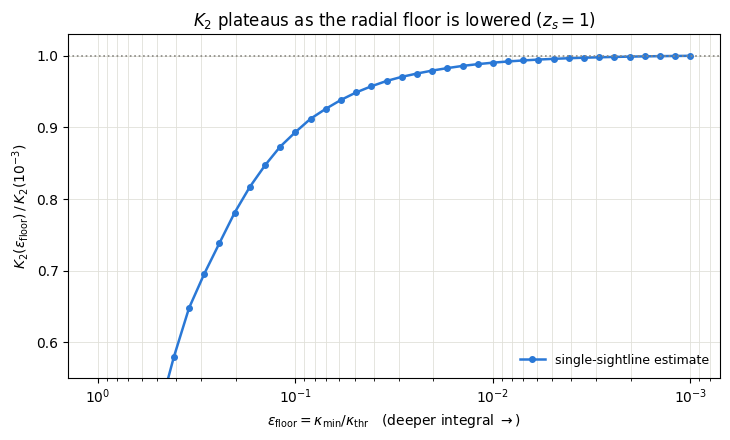

K2(1e-2)/K2(1e-3) = 0.9904  -> lowering the floor 10x below default changes K2 by <1%


In [9]:
# K2 vs eps_floor.  Single-sightline estimate from the drawn halos (eps_floor >= 1e-3),
# overplotted with the exact analytic sweep if k2_vs_floor.cpp has been run on the Mac.
eps = np.logspace(0, -3, 40)
K2e = np.array([(kd[kd>e*kthr]**2).sum() for e in eps])
fig, ax = plt.subplots(figsize=(7.4,4.5))
ax.plot(eps, K2e/K2e[-1], "-o", color=BLUE, ms=4, lw=1.8, label="single-sightline estimate")
from pathlib import Path
exact = DATA/"k2_vs_floor_zs1.txt"
if exact.exists():
    e2,k2 = np.loadtxt(exact, unpack=True); o=np.argsort(e2)[::-1]; e2,k2=e2[o],k2[o]
    ax.plot(e2, k2/k2[np.argmin(np.abs(e2-1e-3))], "-s", color="#e34948", ms=4, lw=1.8,
            label="exact analytic sweep (k2_vs_floor.cpp)")
else:
    print("run playground/k2_vs_floor.cpp on the Mac to add the exact curve (extends below 1e-3)")
ax.axhline(1.0, color="#898781", ls=":", lw=1.2)
ax.set_xscale("log"); ax.invert_xaxis()
ax.set_xlabel(r"$\epsilon_{\rm floor}=\kappa_{\rm min}/\kappa_{\rm thr}$   (deeper integral $\rightarrow$)")
ax.set_ylabel(r"$K_2(\epsilon_{\rm floor})\,/\,K_2(10^{-3})$")
ax.set_title(r"$K_2$ plateaus as the radial floor is lowered ($z_s=1$)")
ax.set_ylim(0.55,1.03); ax.grid(color=GRID, lw=.6, which="both"); ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()
print(f"K2(1e-2)/K2(1e-3) = {K2e[np.argmin(np.abs(eps-1e-2))]/K2e[-1]:.4f}  "
      f"-> lowering the floor 10x below default changes K2 by <1%")